# 1. Wstęp
XD Jo cie chyca

In [39]:
import pandas as pd
import sklearn
import numpy as np
import keras
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Spójrzmy na dane za nim co kolwiek zrobimy

In [44]:
raw_df = pd.read_csv("dataset.csv", index_col="Unnamed: 0")
raw_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,no,2.2,0,1,no,7,0.6,188,2,...,20,756,2549.0,9,7,19.0,0,0,wifi,medium cost
1,1021,yes,0.5,1,0,yes,53,0.7,136,3,...,905,1988,2631.0,17,3,7.0,1,1,no_wifi,high cost
2,563,yes,0.5,1,2,yes,41,0.9,145,5,...,1263,1716,2603.0,11,2,9.0,1,1,no_wifi,high cost
3,615,yes,2.5,0,0,no,10,0.8,131,6,...,1216,1786,2769.0,16,8,11.0,1,0,no_wifi,high cost
4,1821,yes,1.2,0,13,yes,44,0.6,141,2,...,1208,1212,1411.0,8,2,15.0,1,1,no_wifi,medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,yes,0.5,1,0,yes,2,0.8,106,6,...,1222,1890,668.0,13,4,19.0,1,1,no_wifi,low cost
1996,1965,yes,2.6,1,0,no,39,0.2,187,4,...,915,1965,2032.0,11,10,16.0,1,1,wifi,high cost
1997,1911,no,0.9,1,1,yes,36,0.7,108,8,...,868,1632,3057.0,9,1,5.0,1,1,no_wifi,very high cost
1998,1512,no,0.9,0,4,yes,46,0.1,145,5,...,336,670,869.0,18,10,19.0,1,1,wifi,low cost


Super. Popatrzyliśmy na dane w tabelce
imo można wywalić pewne kolumny:
- Unnamed: 0 - losowy indeksik, niby można użyć jako key przy wczytaniu
- pc i fc są podobne więc wywaliłbym fc, tak dla beki

In [41]:
raw_df = raw_df.drop(columns=["fc"])

In [42]:
raw_df

,battery_power,blue,clock_speed,dual_sim,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,no,2.2,0,no,7,0.6,188,2,2,20,756,2549.0,9,7,19.0,0,0,wifi,medium cost
1,1021,yes,0.5,1,yes,53,0.7,136,3,6,905,1988,2631.0,17,3,7.0,1,1,no_wifi,high cost
2,563,yes,0.5,1,yes,41,0.9,145,5,6,1263,1716,2603.0,11,2,9.0,1,1,no_wifi,high cost
3,615,yes,2.5,0,no,10,0.8,131,6,9,1216,1786,2769.0,16,8,11.0,1,0,no_wifi,high cost
4,1821,yes,1.2,0,yes,44,0.6,141,2,14,1208,1212,1411.0,8,2,15.0,1,1,no_wifi,medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,yes,0.5,1,yes,2,0.8,106,6,14,1222,1890,668.0,13,4,19.0,1,1,no_wifi,low cost
1996,1965,yes,2.6,1,no,39,0.2,187,4,3,915,1965,2032.0,11,10,16.0,1,1,wifi,high cost
1997,1911,no,0.9,1,yes,36,0.7,108,8,3,868,1632,3057.0,9,1,5.0,1,1,no_wifi,very high cost
1998,1512,no,0.9,0,yes,46,0.1,145,5,5,336,670,869.0,18,10,19.0,1,1,wifi,low cost


array([[<Axes: xlabel='battery_power', ylabel='battery_power'>,
        <Axes: xlabel='clock_speed', ylabel='battery_power'>,
        <Axes: xlabel='dual_sim', ylabel='battery_power'>,
        <Axes: xlabel='int_memory', ylabel='battery_power'>,
        <Axes: xlabel='m_dep', ylabel='battery_power'>,
        <Axes: xlabel='mobile_wt', ylabel='battery_power'>,
        <Axes: xlabel='n_cores', ylabel='battery_power'>,
        <Axes: xlabel='pc', ylabel='battery_power'>,
        <Axes: xlabel='px_height', ylabel='battery_power'>,
        <Axes: xlabel='px_width', ylabel='battery_power'>,
        <Axes: xlabel='ram', ylabel='battery_power'>,
        <Axes: xlabel='sc_h', ylabel='battery_power'>,
        <Axes: xlabel='sc_w', ylabel='battery_power'>,
        <Axes: xlabel='talk_time', ylabel='battery_power'>,
        <Axes: xlabel='three_g', ylabel='battery_power'>,
        <Axes: xlabel='touch_screen', ylabel='battery_power'>],
       [<Axes: xlabel='battery_power', ylabel='clock_speed'>,


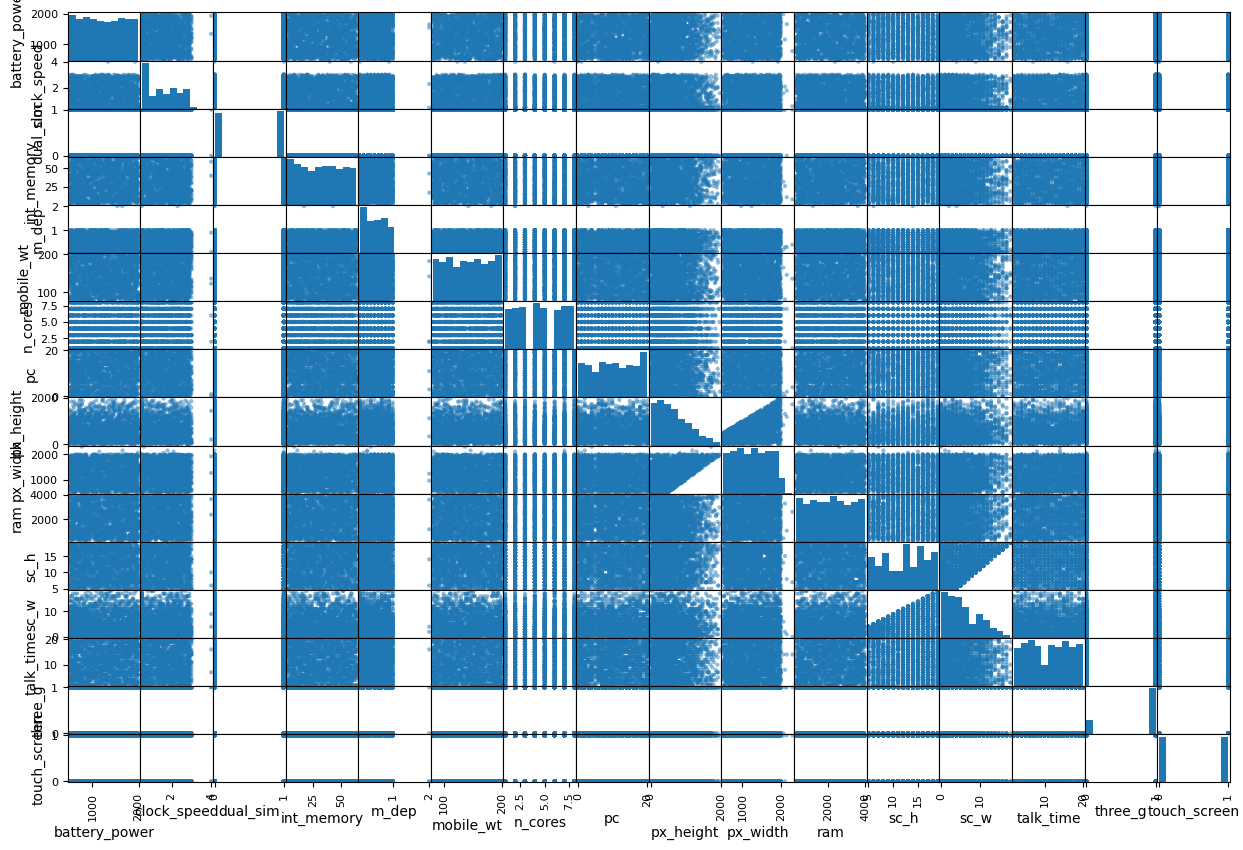

In [43]:
from pandas.plotting import scatter_matrix
df_corr = raw_df

scatter_matrix(df_corr, figsize=(15, 10))

# 3. Preprocessing